In [2]:
from lxml import etree
import numpy as np
import os
import sys
import random
import logging
from transformers import pipeline
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.spatial import Delaunay
from scipy.linalg import norm
import mplcursors
from scipy.spatial import KDTree
from collections import deque

%matplotlib widget 
try:
    if string_table:
        pass
except NameError:
    string_table = {}
    
clf_pipeline = pipeline(
    "zero-shot-classification",
    model="sileod/deberta-v3-large-tasksource-nli",
    local_files_only=True,
)


ModuleNotFoundError: No module named 'transformers'

In [2]:
logger = logging.getLogger(__name__)
handler = logging.StreamHandler(stream=sys.stdout)
handler.setLevel(logging.INFO)
logger.addHandler(handler)


class FaroSceneGraphReader:
    # MNLI Classification Labels
    LABEL_VEHICLE = "vehicle (car, suv, truck, pickup, bus)"
    LABEL_TRAFFIC_LIGHT = "traffic light / signal"
    LABEL_ROAD_MARKING = "road marking / lane line"
    LABEL_DIRECTION_ARROW = "direction arrow (north, south, east, west)"  # capture compass direction in diagram
    LABEL_TURN_DIRECTION = "turn direction"
    LABEL_PEDESTRIAN = "pedestrian"  # TODO: cyclist, deer etc
    LABEL_BACKGROUND = "background / decoration"

    CLASSIFICATION_LABELS = [
        LABEL_VEHICLE,
        LABEL_TRAFFIC_LIGHT,
        LABEL_ROAD_MARKING,
        LABEL_DIRECTION_ARROW,
        LABEL_TURN_DIRECTION,
        LABEL_PEDESTRIAN,
        LABEL_BACKGROUND,
    ]

    def __init__(self, file_path, cls_cache=None):
        self.tree = etree.parse(file_path, etree.XMLParser(huge_tree=True))
        self.root = self.tree.getroot()
        self.clf = clf_pipeline

        self.symbols = []
        self.primitives = []
        # Pass 2 Output: Structured objects
        self.scene_objects = {
            "vehicles": [],
            "roadway": [],
            "road_markings": [],
            "misc": [],
            "texts": [],
            "scalebar": None,
        }
        self.cls_cache = cls_cache if cls_cache is not None else {}

    def _get_transform_matrix(self, item):
        """
        Creates a 3x3 affine transform matrix from item attributes.
        Order: Scale -> Rotate -> Translate
        """
        tx = float(item.get("posx", "0"))
        ty = float(item.get("posy", "0"))
        sx = float(item.get("scalex", "1"))
        sy = float(item.get("scaley", "1"))
        rot = float(item.get("oriz", "0"))  # Assuming radians. If degrees, convert!

        # 1. Scale Matrix
        S = np.array([[sx, 0, 0], [0, sy, 0], [0, 0, 1]])

        # 2. Rotation Matrix
        c, s = np.cos(rot), np.sin(rot)
        R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])

        # 3. Translation Matrix
        T = np.array([[1, 0, tx], [0, 1, ty], [0, 0, 1]])

        # M = T * R * S
        return T @ R @ S

    def _apply_transform(self, points, matrix):
        """
        Applies a 3x3 matrix to a list of 2D points [(x,y), ...].
        """
        if not points:
            return []

        # Convert to homogeneous coordinates (x, y, 1)
        pts = np.array(points)
        ones = np.ones((pts.shape[0], 1))
        pts_homo = np.hstack([pts, ones])

        # Apply matrix (Transposed because points are rows)
        # Result = (M @ P.T).T
        transformed = (matrix @ pts_homo.T).T

        # Return as list of (x, y) tuples
        return [tuple(row[:2]) for row in transformed]

    def parse(self):
        """
        Main entry point.
        """
        logger.info("Phase 1: Flattening Scene Graph...")
        scene = self.root.find("scene")
        # Identity matrix as root transform
        identity = np.eye(3)
        self._traverse_recursive(scene, identity)

        print(
            f"Extracted {len(self.primitives)} primitives and {len(self.symbols)} symbols."
        )

        logger.info("Phase 2: Semantic Association...")
        self._cluster_and_classify()
        return self.scene_objects

    def _traverse_recursive(self, element, parent_matrix, parent_props=[], current_layer=None):
        current_matrix = parent_matrix
        current_props = parent_props.copy()
        current_props.append(element.attrib)

        el_tag = element.tag
        el_type = element.get("type")
        layer = current_layer

        if el_tag == "item":
            # Compute local transform
            if el_type == "symbol":
                self.symbols.append(
                    self._traverse_symbol(element, current_matrix, current_props, layer)
                )
            else:
                current_matrix = parent_matrix @ self._get_transform_matrix(element)
                primitive = self._extract_primitive(
                    element, current_matrix, current_props, layer
                )
                if primitive:
                    self.primitives.append(primitive)
        else:
            if el_tag == "layer":
                layer = element.get("n", None)
            for child in element:
                self._traverse_recursive(child, current_matrix, current_props, layer)

    def _traverse_symbol(self, element, parent_matrix, parent_props, layer):
        current_matrix = parent_matrix
        current_props = parent_props.copy()
        current_props.append(element.attrib)

        # Symbol may have its own transform
        local_matrix = self._get_transform_matrix(element)
        current_matrix = parent_matrix @ local_matrix

        symbol_items = []

        for child in element:
            if child.tag == "item":
                if child.get("type") == "symbol":
                    symbol_result = self._traverse_symbol(
                        child, current_matrix, current_props, layer
                    )
                    if symbol_result:
                        symbol_items.append(symbol_result)
                else:
                    primitive = self._extract_primitive(
                        child, current_matrix, current_props, layer
                    )
                    if primitive:
                        symbol_items.append(primitive)

        for prop in reversed(current_props):
            if "nam" in prop and prop["nam"]:
                name = prop["nam"]
                break
        else:
            name = None

        bbox = (float("inf"), float("inf"), float("-inf"), float("-inf"))
        for item in symbol_items:
            ibox = item["bbox"]
            bbox = (
                min(bbox[0], ibox[0]),
                min(bbox[1], ibox[1]),
                max(bbox[2], ibox[2]),
                max(bbox[3], ibox[3]),
            )

        center = (np.mean([bbox[0], bbox[2]]), np.mean([bbox[1], bbox[3]]))

        # Propagate dashed property from child items (for trajectory vs final position detection)
        is_dashed = any(
            item.get("dashed", False) for item in symbol_items if item["type"] != "symbol"
        ) or any(
            item.get("dashed", False) for item in symbol_items if item["type"] == "symbol"
        )

        return {
            "type": "symbol",
            "name": name,
            "items": symbol_items,
            "bbox": bbox,
            "center": center,
            "transformed_center": self._apply_transform([center], current_matrix)[0],
            "vehicle2d": element.get("vehicle2d", "F") == "T",
            "transform": current_matrix,
            "layer": layer,
            "predicted_class": None,
            "predicted_probability": None,
            "dashed": is_dashed,
        }

    def _extract_primitive(self, element, global_matrix, inherited_props, layer):
        """
        Extracts geometry, applies global transform, and saves to flat list.
        """
        el_type = element.get("type")
        current_props = inherited_props.copy()
        current_props.append(element.attrib)

        # Helper to parse vertex strings "x,y;x,y"
        def parse_verts(attr):
            raw = element.get(attr)
            if not raw:
                return []
            return [tuple(map(float, v.split(",")))[:2] for v in raw.split(";") if v]

        # Cubic Bezier evaluation
        def bezier_cubic(P0, C1, C2, P1, t):
            # t is (m,) -> returns (m,3)
            t = t[:, None]
            return (
                ((1 - t) ** 3) * P0
                + 3 * ((1 - t) ** 2) * t * C1
                + 3 * (1 - t) * (t**2) * C2
                + (t**3) * P1
            )

        verts = []
        text_content = None
        dashed = False
        thick = False
        closed = element.get("closed", "F") == "T"
        if el_type == "polyline":
            verts = parse_verts("vlist")

        elif el_type == "polycurve":
            raw_verts = parse_verts("pnts")
            ctrl_pts = parse_verts("ctrl")
            if raw_verts and not closed:
                first_pt = raw_verts[0]
                last_pt = raw_verts[-1]
                bbox = (min(x for x, y in raw_verts), min(y for x, y in raw_verts),
                        max(x for x, y in raw_verts), max(y for x, y in raw_verts))
                if np.hypot(first_pt[0]-last_pt[0], first_pt[1]-last_pt[1]) < 0.25 * max(bbox[2]-bbox[0], bbox[3]-bbox[1]):
                    closed = True
                    
            if raw_verts and ctrl_pts and 2 * len(raw_verts) - 2 == len(ctrl_pts):
                # Build cubic Bezier segments
                curve_verts = []
                num_segments = len(raw_verts) - 1
                for i in range(num_segments):
                    P0 = np.array(raw_verts[i])
                    P1 = np.array(raw_verts[i + 1])
                    C1 = np.array(ctrl_pts[2 * i])
                    C2 = np.array(ctrl_pts[2 * i + 1])
                    t_vals = np.linspace(0, 1, num=10)  # 10 points per segment
                    segment_pts = bezier_cubic(P0, C1, C2, P1, t_vals)
                    if i > 0:
                        segment_pts = segment_pts[1:]  # Avoid duplicating points
                    curve_verts.extend([tuple(pt) for pt in segment_pts])
                verts = curve_verts
            else:
                verts = raw_verts

            if closed and verts:
                if verts[0] != verts[-1]:
                    verts.append(verts[0])

        elif el_type == "line":
            line_data = element.find("lndata")
            if (
                line_data.get("arrowshowe", "F") == "T"
                or line_data.get("arrowshows", "F") == "T"
            ):
                # Ignore arrows
                return None
            startX = float(element.get("pntSx", "0"))
            startY = float(element.get("pntSy", "0"))
            endX = float(element.get("pntEx", "0"))
            endY = float(element.get("pntEy", "0"))
            verts = [(startX, startY), (endX, endY)]
        elif el_type == "label":
            # For text, we might care about the insertion point
            sizeX = float(element.get("sizex", "0"))
            sizeY = float(element.get("sizey", "0"))
            offPosx = sizeX / 2.0
            offPosy = sizeY / 2.0
            text_point = (offPosx, offPosy)  # Text anchor point
            verts = [text_point]
            # verts = [(0, 0)]
            text_content = element.get("text", "")
            if not text_content:
                print("Warning: Label element without text content.")
        elif el_type == "scalebar":
            if self.scene_objects["scalebar"] is not None:
                print("Warning: Multiple scalebars found; using the first one.")
                return None
            x = float(element.get("px", "0"))
            y = float(element.get("py", "0"))
            sizeX = float(element.get("szx", "0"))
            sizeY = float(element.get("szy", "0"))
            self.scene_objects["scalebar"] = {
                "type": el_type,
                "position": (x, y),
                "size": (sizeX, sizeY),
            }
        elif el_type == "flexconcretebarrier":
            print("Flex concrete barrier encountered; skipping for now.")
            pass

        lndata = element.find("lndata")  # could check for arrows here
        if lndata is not None:
            if lndata.get("lt") == "1":
                dashed = True
            if lndata.get("thickness") > "0":
                thick = True

        if verts:
            xs, ys = zip(*verts)
            center = (np.mean(xs), np.mean(ys))
            bbox = (min(xs), min(ys), max(xs), max(ys))  # (xmin, ymin, xmax, ymax)

            for prop in reversed(current_props):
                if "nam" in prop and prop["nam"]:
                    name = prop["nam"]
                    break
            else:
                name = None

            return {
                "type": el_type,
                "name": name,
                "verts": verts,
                "transformed_verts": self._apply_transform(verts, global_matrix),
                "center": center,
                "transformed_center": self._apply_transform([center], global_matrix)[0],
                "bbox": bbox,
                "vehicle2d": element.get("vehicle2d", "F") == "T",
                "transform": global_matrix,
                "text": text_content,
                "dashed": dashed,
                "thick": thick,
                "closed": closed,
                "layer": layer
            }
        else:
            pass
            # logger.warning(f"Warning: No verts found for element of type {el_type}")

    def _check_name_vehicle(self, name):
        """
        Use MNLI to classify a name and return (is_vehicle, predicted_class, probability).
        """
        out = self.clf(
            name.lower().replace("_", " "),
            candidate_labels=self.CLASSIFICATION_LABELS,
            multi_label=True,
            hypothesis_template="This item is a {}.",
        )
        # print(f"Classifying name '{name}': {list(zip(out['labels'], out['scores']))}")
        scores = out["scores"]
        max_idx = np.argmax(scores)
        predicted_class = out["labels"][max_idx]
        predicted_prob = scores[max_idx]

        is_vehicle = predicted_class == self.LABEL_VEHICLE and predicted_prob > 0.7

        # Cache the result
        self.cls_cache[name] = {
            "is_vehicle": is_vehicle,
            "predicted_class": predicted_class,
            "predicted_probability": predicted_prob,
        }

        return is_vehicle, predicted_class, predicted_prob

    def _check_vehicle(self, symbol):
        """
        Simple heuristic to check if a symbol is a vehicle based on attributes.
        Propagates predicted_class and predicted_probability to the symbol dict.
        """

        if symbol["vehicle2d"]:
            symbol["predicted_class"] = self.LABEL_VEHICLE
            symbol["predicted_probability"] = 1.0
            return True

        if symbol["name"]:
            if symbol["name"] in self.cls_cache:
                cache_entry = self.cls_cache[symbol["name"]]
                symbol["predicted_class"] = cache_entry["predicted_class"]
                symbol["predicted_probability"] = cache_entry["predicted_probability"]
                return cache_entry["is_vehicle"]
            else:
                is_vehicle, predicted_class, predicted_prob = self._check_name_vehicle(
                    symbol["name"]
                )
                symbol["predicted_class"] = predicted_class
                symbol["predicted_probability"] = predicted_prob
                return is_vehicle

        # Check nested symbols
        for item in symbol["items"]:
            if item["type"] == "symbol":
                if self._check_vehicle(item):
                    # Propagate nested classification if no classification yet
                    if not symbol["predicted_class"]:
                        symbol["predicted_class"] = item.get("predicted_class")
                        symbol["predicted_probability"] = item.get(
                            "predicted_probability"
                        )
                    return True

        # if no indicators found
        # TODO: Add aspect ratio or size heuristics
        # TODO: rasterize + vlm?
        return False

    def _cluster_and_classify(self):
        """
        Phase 2: Reconstruct objects based on attributes and SPATIAL PROXIMITY.
        """
        # 1. Identify Vehicle Candidates
        # Heuristics: Explicit attribute OR Name match OR Aspect Ratio check
        vehicle_candidates = []
        texts = []
        others = []
        roadway = []
        road_markings = []

        print("Classifying symbols for vehicle candidates...")
        for p in self.symbols:
            if self._check_vehicle(p):
                # print(f"Identified vehicle candidate: {p['name']}")
                p["associated_text"] = []
                for it in p["items"]:
                    if it["type"] == "label":
                        p["associated_text"].append(it["text"])
                vehicle_candidates.append(p)
            elif (
                p["predicted_probability"]
                and p["predicted_probability"] > 0.5
                and p["predicted_class"]
                in [self.LABEL_ROAD_MARKING, self.LABEL_TURN_DIRECTION]
            ):
                road_markings.append(p)

            else:
                others.append(p)

        for p in self.primitives:
            if p["type"] == "label":
                texts.append(p)
            elif p["type"] in ["polycurve", "polyline", "line", "flexconcretebarrier"]: #and p["layer"] == "Line Work":
                roadway.append(p)
            else:
                others.append(p)

        # 2. Associate Text to Vehicles (Spatial Join)
        # Simple N*M check (fast enough for <1000 items)
        for txt in texts:
            txt_pos = txt["transformed_center"]
            best_dist = float("inf")
            best_vehicle = None

            for veh in vehicle_candidates:
                # Check if text is inside or near vehicle bbox
                # Using simple center-to-center distance for demo
                vx, vy = veh["transformed_center"]

                dist = np.hypot(vx - txt_pos[0], vy - txt_pos[1])
                # Heuristic: Text must be within X meters (units depend on file)
                if dist < best_dist:
                    best_dist = dist
                    best_vehicle = veh

            # Threshold distance (adjust based on your coordinate system units)
            if best_vehicle and best_dist < 5.0:
                best_vehicle["associated_text"].append(txt["text"])
                # Or append the raw XML text content

        self.scene_objects["vehicles"] = vehicle_candidates
        self.scene_objects["misc"] = others
        self.scene_objects["roadway"] = roadway
        self.scene_objects["road_markings"] = road_markings
        self.scene_objects["texts"] = texts

In [3]:
folder = '../data/nhtsa-ciss/data/output/'
# load random .far file from folder
# get list of .far files
far_files = [f for f in os.listdir(folder) if f.endswith('.far')]
filename = random.choice(far_files)
# filename = '23103_20211031066.far'
# filename = '22186_20211027049.far'

# filename = '22012_20211052088.far'
# filename = '21137_20211020024.far'
# filename = '21647_20211022054.far'
# filename = '20544_20211020005.far'
# filename = '27208_20221010147.far'
# filename = '28136_20221019168.far'
# filename = '25922_20221019074.far'
# filename = '21670_20211048031.far'
# filename = '26217_20221059035.far'
# filename = '25486_20221052042.far'
# filename = '26808_20221052111.far'
# filename = '27014_20221018071.far'
# filename = '28274_20221020227.far'
# filename = '25486_20221052042.far'
# filename = '27256_20221059066.far'
# filename = '20407_20211077002.far' # Polyline instead of symbol for cars

file = os.path.join(folder, filename)
print(f"Loading file: {file}")
print(f"https://crashviewer.nhtsa.dot.gov/ciss/details/{filename.split('_')[0]}/crash-summary-scene-diagram")


Loading file: ../data/nhtsa-ciss/data/output/27477_20221020191.far
https://crashviewer.nhtsa.dot.gov/ciss/details/27477/crash-summary-scene-diagram


In [4]:
reader = FaroSceneGraphReader(file, cls_cache=string_table)
scene = reader.parse()
print(len(scene["vehicles"]))

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Extracted 16 primitives and 26 symbols.
Classifying symbols for vehicle candidates...


21


In [5]:
import heapq
from collections import deque

# Try to import numba for JIT compilation, fall back to no-op decorator if unavailable
try:
    from numba import njit, prange
    HAS_NUMBA = True
except ImportError:
    HAS_NUMBA = False
    # Create no-op decorators as fallback
    def njit(*args, **kwargs):
        def decorator(func):
            return func
        if len(args) == 1 and callable(args[0]):
            return args[0]
        return decorator
    def prange(*args):
        return range(*args)

# ============================================================================
# NUMBA-ACCELERATED CORE FUNCTIONS
# ============================================================================

@njit(cache=True)
def ccw_fast(ax, ay, bx, by, cx, cy):
    """JIT-compiled counter-clockwise test."""
    return (cy - ay) * (bx - ax) > (by - ay) * (cx - ax)

@njit(cache=True)
def line_segments_intersect_fast(ax, ay, bx, by, cx, cy, dx, dy):
    """JIT-compiled line segment intersection check."""
    return (ccw_fast(ax, ay, cx, cy, dx, dy) != ccw_fast(bx, by, cx, cy, dx, dy) and 
            ccw_fast(ax, ay, bx, by, cx, cy) != ccw_fast(ax, ay, bx, by, dx, dy))

@njit(cache=True)
def compute_edge_angle_fast(start_x, start_y, end_x, end_y):
    """JIT-compiled edge angle computation."""
    return np.arctan2(end_y - start_y, end_x - start_x)

@njit(cache=True)
def angles_are_parallel_fast(angle1, angle2, epsilon_rad):
    """JIT-compiled parallel angle check."""
    diff = np.arctan2(np.sin(angle1 - angle2), np.cos(angle1 - angle2))
    abs_diff = np.abs(diff)
    return abs_diff < epsilon_rad or abs_diff > (np.pi - epsilon_rad)

@njit(cache=True)
def point_to_segment_distance_fast(px, py, ax, ay, bx, by):
    """JIT-compiled point to line segment distance."""
    edge_x = bx - ax
    edge_y = by - ay
    edge_length_sq = edge_x * edge_x + edge_y * edge_y
    
    if edge_length_sq < 1e-12:  # Degenerate edge
        return np.sqrt((px - ax)**2 + (py - ay)**2)
    
    # Project point onto line
    t = max(0.0, min(1.0, ((px - ax) * edge_x + (py - ay) * edge_y) / edge_length_sq))
    closest_x = ax + t * edge_x
    closest_y = ay + t * edge_y
    
    return np.sqrt((px - closest_x)**2 + (py - closest_y)**2)

@njit(cache=True)
def compute_triangle_edge_lengths(pts):
    """Compute edge lengths for a triangle given 3 points as (3, 2) array."""
    d01 = np.sqrt((pts[0, 0] - pts[1, 0])**2 + (pts[0, 1] - pts[1, 1])**2)
    d12 = np.sqrt((pts[1, 0] - pts[2, 0])**2 + (pts[1, 1] - pts[2, 1])**2)
    d20 = np.sqrt((pts[2, 0] - pts[0, 0])**2 + (pts[2, 1] - pts[0, 1])**2)
    return d01, d12, d20

# ============================================================================
# VECTORIZED PREPROCESSING
# ============================================================================

def compute_all_edge_lengths_vectorized(all_points, simplices):
    """
    Vectorized computation of all triangle edge lengths.
    
    Returns:
        edge_lengths: (n_triangles, 3) array of edge lengths
        max_edge_lengths: (n_triangles,) array of max edge per triangle
    """
    # Get points for all triangles: shape (n_tri, 3, 2)
    tri_points = all_points[simplices]
    
    # Compute edge vectors
    # Edge 0-1, 1-2, 2-0
    edges = np.stack([
        tri_points[:, 1] - tri_points[:, 0],  # edge 0->1
        tri_points[:, 2] - tri_points[:, 1],  # edge 1->2
        tri_points[:, 0] - tri_points[:, 2],  # edge 2->0
    ], axis=1)  # shape: (n_tri, 3, 2)
    
    # Compute lengths
    edge_lengths = np.linalg.norm(edges, axis=2)  # shape: (n_tri, 3)
    max_edge_lengths = edge_lengths.max(axis=1)   # shape: (n_tri,)
    
    return edge_lengths, max_edge_lengths

def precompute_roadway_edge_angles(roadway_edges):
    """
    Precompute angles for all roadway edges once.
    
    Returns:
        Dict mapping roadway_idx to numpy array of edge angles
    """
    roadway_edge_angles = {}
    for roadway_idx, edges in roadway_edges.items():
        angles = np.array([
            compute_edge_angle_fast(e[0][0], e[0][1], e[1][0], e[1][1]) 
            for e in edges
        ])
        roadway_edge_angles[roadway_idx] = angles
    return roadway_edge_angles

def build_roadway_edge_arrays(roadway_edges):
    """
    Convert roadway edges dict to flat numpy arrays for faster access.
    
    Returns:
        edge_starts: (n_edges, 2) array
        edge_ends: (n_edges, 2) array  
        edge_roadway_idx: (n_edges,) array mapping edge to roadway
        roadway_edge_ranges: dict mapping roadway_idx to (start, end) indices
    """
    edge_starts = []
    edge_ends = []
    edge_roadway_idx = []
    roadway_edge_ranges = {}
    
    current_idx = 0
    for roadway_idx, edges in roadway_edges.items():
        start_idx = current_idx
        for edge_start, edge_end in edges:
            edge_starts.append(edge_start)
            edge_ends.append(edge_end)
            edge_roadway_idx.append(roadway_idx)
            current_idx += 1
        roadway_edge_ranges[roadway_idx] = (start_idx, current_idx)
    
    return (np.array(edge_starts), np.array(edge_ends), 
            np.array(edge_roadway_idx), roadway_edge_ranges)

# ============================================================================
# OPTIMIZED BFS WITH DEQUE
# ============================================================================

def bfs_connect_optimized(start_idx, adjacency, edges, visited, points, angle_threshold):
    """
    Optimized BFS using deque for O(1) prepend operations.
    """
    segment = deque([start_idx])
    visited.add(start_idx)
    current = start_idx
    epsilon_rad = np.deg2rad(angle_threshold)
    
    # Forward search
    while True:
        candidates = []
        for nbr in adjacency[current]:
            if nbr in visited:
                continue
            edge_key = (min(current, nbr), max(current, nbr))
            edge_info = edges.get(edge_key)
            if edge_info:
                if len(segment) > 1:
                    prev = segment[-2]
                    angle1 = compute_edge_angle_fast(
                        points[prev, 0], points[prev, 1],
                        points[current, 0], points[current, 1]
                    )
                    angle2 = compute_edge_angle_fast(
                        points[current, 0], points[current, 1],
                        points[nbr, 0], points[nbr, 1]
                    )
                    diff = np.arctan2(np.sin(angle1 - angle2), np.cos(angle1 - angle2))
                    abs_diff = np.abs(diff)
                    if not (abs_diff < epsilon_rad or abs_diff > (np.pi - epsilon_rad)):
                        continue
                heapq.heappush(candidates, (edge_info['distance'], nbr))
        
        if not candidates:
            break
        
        _, next_idx = heapq.heappop(candidates)
        visited.add(next_idx)
        segment.append(next_idx)
        current = next_idx
    
    # Backward search from start
    if len(segment) >= 2:
        forward_angle = compute_edge_angle_fast(
            points[segment[0], 0], points[segment[0], 1],
            points[segment[1], 0], points[segment[1], 1]
        )
        current = start_idx
        
        while True:
            candidates = []
            for nbr in adjacency[current]:
                if nbr in visited:
                    continue
                edge_key = (min(current, nbr), max(current, nbr))
                edge_info = edges.get(edge_key)
                if edge_info:
                    angle_to_nbr = compute_edge_angle_fast(
                        points[current, 0], points[current, 1],
                        points[nbr, 0], points[nbr, 1]
                    )
                    diff = np.arctan2(np.sin(forward_angle - angle_to_nbr), 
                                     np.cos(forward_angle - angle_to_nbr))
                    abs_diff = np.abs(diff)
                    # Want opposite direction for prepending
                    if abs_diff > (np.pi - epsilon_rad):
                        heapq.heappush(candidates, (edge_info['distance'], nbr))
            
            if not candidates:
                break
            
            _, next_idx = heapq.heappop(candidates)
            visited.add(next_idx)
            segment.appendleft(next_idx)
            current = next_idx
    
    return list(segment)

# ============================================================================
# BATCH PARALLEL EDGE CHECKING
# ============================================================================

def find_nearest_edge_batch(points, roadway_idx, edge_starts, edge_ends, 
                            roadway_edge_ranges, search_distance=2.0):
    """
    Find nearest edges for multiple points at once.
    
    Args:
        points: (n, 2) array of query points
        roadway_idx: which roadway to search
        edge_starts, edge_ends: precomputed edge arrays
        roadway_edge_ranges: dict of (start, end) indices per roadway
        
    Returns:
        nearest_edges: list of (edge_start, edge_end, angle) or None for each point
    """
    if roadway_idx not in roadway_edge_ranges:
        return [None] * len(points)
    
    start_idx, end_idx = roadway_edge_ranges[roadway_idx]
    edges_start = edge_starts[start_idx:end_idx]
    edges_end = edge_ends[start_idx:end_idx]
    
    if len(edges_start) == 0:
        return [None] * len(points)
    
    results = []
    for pt in points:
        best_dist = search_distance
        best_edge = None
        
        for i in range(len(edges_start)):
            dist = point_to_segment_distance_fast(
                pt[0], pt[1],
                edges_start[i, 0], edges_start[i, 1],
                edges_end[i, 0], edges_end[i, 1]
            )
            if dist < best_dist:
                best_dist = dist
                angle = compute_edge_angle_fast(
                    edges_start[i, 0], edges_start[i, 1],
                    edges_end[i, 0], edges_end[i, 1]
                )
                best_edge = (edges_start[i].copy(), edges_end[i].copy(), angle)
        
        results.append(best_edge)
    
    return results

def check_parallel_vectorized(simplex_batch, all_points, point_to_roadway_idx,
                              edge_starts, edge_ends, roadway_edge_ranges,
                              parallel_angle_epsilon):
    """
    Vectorized parallel edge check for a batch of triangles.
    
    Returns:
        is_parallel: boolean array for each triangle
    """
    epsilon_rad = np.deg2rad(parallel_angle_epsilon)
    n_triangles = len(simplex_batch)
    is_parallel = np.zeros(n_triangles, dtype=bool)
    
    for tri_idx, simplex in enumerate(simplex_batch):
        # Get roadway indices for this triangle's vertices
        roadway_indices = [point_to_roadway_idx[idx] for idx in simplex]
        unique_roadways = set(roadway_indices)
        
        if len(unique_roadways) < 2:
            continue
        
        # Find nearest edges for each vertex
        vertex_angles = {}  # roadway_idx -> list of angles
        
        for vert_idx, (vertex, roadway_idx) in enumerate(zip(simplex, roadway_indices)):
            pt = all_points[vertex:vertex+1]  # Keep 2D shape
            edge_result = find_nearest_edge_batch(
                pt, roadway_idx, edge_starts, edge_ends, 
                roadway_edge_ranges, search_distance=2.0
            )[0]
            
            if edge_result is not None:
                if roadway_idx not in vertex_angles:
                    vertex_angles[roadway_idx] = []
                vertex_angles[roadway_idx].append(edge_result[2])  # angle
        
        # Check if we have angles from at least 2 different roadways
        if len(vertex_angles) >= 2:
            roadway_mean_angles = {
                ridx: np.mean(angles) 
                for ridx, angles in vertex_angles.items()
            }
            
            # Check all pairs
            roadway_list = list(roadway_mean_angles.items())
            for i in range(len(roadway_list)):
                for j in range(i + 1, len(roadway_list)):
                    if angles_are_parallel_fast(
                        roadway_list[i][1], 
                        roadway_list[j][1], 
                        epsilon_rad
                    ):
                        is_parallel[tri_idx] = True
                        break
                if is_parallel[tri_idx]:
                    break
    
    return is_parallel

# ============================================================================
# MAIN OPTIMIZED FUNCTION
# ============================================================================

def resample_polyline(points, step_distance=2.0):
    """Interpolates points along a polyline so they are spaced no more than step_distance apart."""
    if len(points) < 2:
        return np.array(points)
    
    new_points = [points[0]]
    for i in range(1, len(points)):
        p1 = np.array(points[i-1])
        p2 = np.array(points[i])
        dist = np.linalg.norm(p2 - p1)
        
        if dist > step_distance:
            num_points = int(np.ceil(dist / step_distance))
            interpolated = np.linspace(p1, p2, num_points + 1)[1:]
            new_points.extend(interpolated)
        else:
            new_points.append(p2)
            
    return np.array(new_points)

def build_edge_spatial_index(roadway_edges):
    """Build R-tree spatial index for fast edge lookup."""
    from rtree import index
    
    idx = index.Index()
    edge_list = []
    edge_id = 0
    
    for roadway_idx, edges in roadway_edges.items():
        for edge_start, edge_end in edges:
            bbox = (
                min(edge_start[0], edge_end[0]),
                min(edge_start[1], edge_end[1]),
                max(edge_start[0], edge_end[0]),
                max(edge_start[1], edge_end[1])
            )
            idx.insert(edge_id, bbox)
            edge_list.append((roadway_idx, edge_start, edge_end))
            edge_id += 1
    
    return idx, edge_list

def check_crossing_optimized(center_curr, center_nbr, edge_index, edge_list, relevant_roadways):
    """Check if line segment crosses any roadway edges using spatial index."""
    bbox = (
        min(center_curr[0], center_nbr[0]),
        min(center_curr[1], center_nbr[1]),
        max(center_curr[0], center_nbr[0]),
        max(center_curr[1], center_nbr[1])
    )
    
    for edge_id in edge_index.intersection(bbox):
        roadway_idx, road_seg_start, road_seg_end = edge_list[edge_id]
        if roadway_idx in relevant_roadways:
            if line_segments_intersect_fast(
                center_curr[0], center_curr[1],
                center_nbr[0], center_nbr[1],
                road_seg_start[0], road_seg_start[1],
                road_seg_end[0], road_seg_end[1]
            ):
                return True
    return False

def filter_outliers_and_connect_optimized(points, distance_threshold=5.0, 
                                          angle_threshold=30.0, minimum_length=5.0):
    """Optimized outlier filtering using deque and vectorized operations."""
    points = np.array(points)
    if len(points) < 2:
        return [], [(pt[0], pt[1], "Not enough points") for pt in points]
    
    tree = KDTree(points)
    pairs = tree.query_pairs(r=distance_threshold)
    
    adjacency = [set() for _ in range(len(points))]
    edges = {}
    
    # Vectorize edge computation where possible
    for i, j in pairs:
        adjacency[i].add(j)
        adjacency[j].add(i)
        distance = np.linalg.norm(points[i] - points[j])
        angle = compute_edge_angle_fast(points[i, 0], points[i, 1], 
                                        points[j, 0], points[j, 1])
        edges[(i, j)] = {'angle': angle, 'distance': distance}
    
    visited = set()
    polylines = []
    
    for i in range(len(points)):
        if i not in visited:
            segment_indices = bfs_connect_optimized(
                i, adjacency, edges, visited, points, angle_threshold
            )
            if len(segment_indices) >= 2:
                total_length = sum(
                    np.linalg.norm(points[segment_indices[k]] - points[segment_indices[k-1]])
                    for k in range(1, len(segment_indices))
                )
                if total_length >= minimum_length:
                    segment_points = [tuple(points[idx]) for idx in segment_indices]
                    polylines.append(segment_points)
    
    outliers = [
        (points[i][0], points[i][1], "Isolated point")
        for i in range(len(points)) if i not in visited
    ]
    
    # Filter by average segment length
    filtered_polylines = []
    for seg in polylines:
        if len(seg) < 2:
            continue
        avg_len = np.mean([
            np.linalg.norm(np.array(seg[k]) - np.array(seg[k-1]))
            for k in range(1, len(seg))
        ])
        if avg_len <= 1:
            filtered_polylines.append(seg)
    
    return filtered_polylines, outliers

def get_delaunay_centerlines_optimized(roadway_items, road_threshold=(5, 15.0), 
                                       vertex_cluster_threshold=10, 
                                       parallel_angle_epsilon=15.0):
    """
    Optimized Delaunay centerline extraction with:
    - Vectorized triangle filtering
    - Precomputed edge angles
    - Numba JIT for hot loops
    - Deque for O(1) BFS operations
    - Batch parallel checking
    """
    # 1. Collect and Resample all points
    all_points = []
    point_to_roadway_idx = []
    roadway_edges = {}
    min_road_width = road_threshold[0]
    max_road_width = road_threshold[1]

    for roadway_idx, item in enumerate(roadway_items):
        verts = item["verts"]
        if not verts or len(verts) < 2:
            continue

        roadway_edges[roadway_idx] = []
        for i in range(len(verts) - 1):
            roadway_edges[roadway_idx].append((np.array(verts[i]), np.array(verts[i+1])))

        resampled = resample_polyline(verts, step_distance=1.0)
        for pt in resampled:
            all_points.append(pt)
            point_to_roadway_idx.append(roadway_idx)

    all_points = np.array(all_points)
    point_to_roadway_idx = np.array(point_to_roadway_idx)

    if len(all_points) < 3:
        return [], [], [], [], {}, [], {}, [], []

    # 2. Precompute edge data structures
    edge_index, edge_list = build_edge_spatial_index(roadway_edges)
    edge_starts, edge_ends, edge_roadway_idx, roadway_edge_ranges = \
        build_roadway_edge_arrays(roadway_edges)

    # 3. Compute Delaunay Triangulation
    tri = Delaunay(all_points)
    n_triangles = len(tri.simplices)

    # 4. VECTORIZED: Compute all edge lengths at once
    edge_lengths, max_edge_lengths = compute_all_edge_lengths_vectorized(
        all_points, tri.simplices
    )

    # 5. VECTORIZED: First-pass filter by edge length
    size_valid_mask = (max_edge_lengths <= max_road_width) & (max_edge_lengths >= min_road_width)

    # 6. VECTORIZED: Check roadway diversity per triangle
    tri_roadways = point_to_roadway_idx[tri.simplices]  # (n_tri, 3)
    # Count unique roadways per triangle
    roadway_diversity = np.array([
        len(set(tri_roadways[i])) for i in range(n_triangles)
    ])
    diversity_valid_mask = roadway_diversity >= 2

    # 7. Compute vertex triangle counts for cluster detection
    vertex_triangle_count = {}
    for tri_idx, simplex in enumerate(tri.simplices):
        for vertex_idx in simplex:
            if vertex_idx not in vertex_triangle_count:
                vertex_triangle_count[vertex_idx] = []
            vertex_triangle_count[vertex_idx].append(tri_idx)

    problematic_vertices = set()
    vertex_cluster_info = {}
    for vertex_idx, triangle_list in vertex_triangle_count.items():
        count = len(triangle_list)
        vertex_cluster_info[vertex_idx] = count
        if count >= vertex_cluster_threshold:
            problematic_vertices.add(vertex_idx)

    clustered_triangle_indices = set()
    for vertex_idx in problematic_vertices:
        clustered_triangle_indices.update(vertex_triangle_count[vertex_idx])

    cluster_mask = np.array([i not in clustered_triangle_indices for i in range(n_triangles)])

    # 8. Combined first-pass filter
    valid_first_pass = size_valid_mask & diversity_valid_mask & cluster_mask
    valid_indices = np.where(valid_first_pass)[0]

    # 9. BATCH: Check parallel edges for valid triangles
    is_parallel = check_parallel_vectorized(
        tri.simplices[valid_indices],
        all_points,
        point_to_roadway_idx,
        edge_starts, edge_ends, roadway_edge_ranges,
        parallel_angle_epsilon
    )

    # 10. Build output structures
    skeleton_segments = []
    triangle_segments = []
    clustered_triangles = []
    non_parallel_triangles = []
    segments = set()
    triangle_perp_widths = {}  # tri_index -> perpendicular road width
    skeleton_widths = []  # parallel to skeleton_segments

    # Process all triangles for visualization
    for i, simplex in enumerate(tri.simplices):
        pts = all_points[simplex]
        is_clustered = i in clustered_triangle_indices
        
        # Check if this triangle passed first-pass filter
        first_pass_idx = np.where(valid_indices == i)[0]
        is_par = False
        if len(first_pass_idx) > 0:
            is_par = is_parallel[first_pass_idx[0]]

        # Store triangle edges for visualization
        for j in range(3):
            start_pt = tuple(pts[j])
            end_pt = tuple(pts[(j+1)%3])
            if (start_pt, end_pt) not in segments and (end_pt, start_pt) not in segments:
                segments.add((start_pt, end_pt))
                if is_clustered:
                    clustered_triangles.append((start_pt, end_pt))
                elif not size_valid_mask[i] or not diversity_valid_mask[i]:
                    continue  # Skip non-valid triangles
                elif not is_par:
                    non_parallel_triangles.append((start_pt, end_pt))
                else:
                    triangle_segments.append((start_pt, end_pt))

        # Skip centroid generation for invalid triangles
        if not valid_first_pass[i]:
            continue
        first_pass_idx = np.where(valid_indices == i)[0]
        if len(first_pass_idx) == 0 or not is_parallel[first_pass_idx[0]]:
            continue

        # Generate skeleton segments
        triangle_roadway_indices = set(point_to_roadway_idx[simplex])
        center_curr = np.mean(pts, axis=0)

        # Compute perpendicular road width from triangle geometry
        tri_roadways = [point_to_roadway_idx[v] for v in simplex]
        perp_w = None
        # Find the edge where both vertices share the same roadway
        for j in range(3):
            v0, v1, v2 = simplex[j], simplex[(j+1)%3], simplex[(j+2)%3]
            if point_to_roadway_idx[v0] == point_to_roadway_idx[v1]:
                # v0-v1 is the same-roadway edge; v2 is the opposite vertex
                # Perpendicular width = distance from v2 to line(v0, v1)
                perp_w = point_to_segment_distance_fast(
                    all_points[v2, 0], all_points[v2, 1],
                    all_points[v0, 0], all_points[v0, 1],
                    all_points[v1, 0], all_points[v1, 1]
                )
                break
        if perp_w is None:
            # All 3 vertices on different roadways - use minimum altitude
            altitudes = []
            for j in range(3):
                v_opp = simplex[j]
                v_a, v_b = simplex[(j+1)%3], simplex[(j+2)%3]
                altitudes.append(point_to_segment_distance_fast(
                    all_points[v_opp, 0], all_points[v_opp, 1],
                    all_points[v_a, 0], all_points[v_a, 1],
                    all_points[v_b, 0], all_points[v_b, 1]
                ))
            perp_w = min(altitudes)
        triangle_perp_widths[i] = perp_w

        
        for neighbor_idx in tri.neighbors[i]:
            if neighbor_idx == -1 or neighbor_idx < i:
                continue
            if neighbor_idx in clustered_triangle_indices:
                continue

            nbr_pts = all_points[tri.simplices[neighbor_idx]]
            if max_edge_lengths[neighbor_idx] > max_road_width:
                continue

            center_nbr = np.mean(nbr_pts, axis=0)
            if np.linalg.norm(center_curr - center_nbr) > max_road_width / 2:
                continue

            neighbor_roadway_indices = set(point_to_roadway_idx[tri.simplices[neighbor_idx]])
            relevant_roadways = triangle_roadway_indices | neighbor_roadway_indices

            if not check_crossing_optimized(center_curr, center_nbr, edge_index, 
                                           edge_list, relevant_roadways):
                skeleton_segments.append((center_curr, center_nbr))
                # Average perpendicular width of the two triangles
                nbr_w = triangle_perp_widths.get(neighbor_idx)
                seg_w = perp_w
                if nbr_w is not None:
                    seg_w = (perp_w + nbr_w) / 2.0
                skeleton_widths.append(seg_w)

    # 11. Compute midpoints, track widths, filter, and split wide roads
    midpoints = [
        ((seg[0][0]+seg[1][0])/2.0, (seg[0][1]+seg[1][1])/2.0)
        for seg in skeleton_segments
    ]

    # Build width lookup: midpoint coords -> perpendicular road width
    midpoint_width_map = {}
    for mp, w in zip(midpoints, skeleton_widths):
        midpoint_width_map[mp] = w

    centerline_segments = []
    outlier_info = {}

    if midpoints:
        centerline_segments, outlier_info = filter_outliers_and_connect_optimized(
            midpoints, distance_threshold=8, angle_threshold=15
        )

    # Split wide roads into two offset centerlines
    centerline_segments = split_wide_roads(
        centerline_segments, midpoint_width_map,
        split_threshold=max_road_width * 0.45
    )

    return (skeleton_segments, triangle_segments, all_points, centerline_segments,
            outlier_info, clustered_triangles, vertex_cluster_info, 
            non_parallel_triangles, midpoints)

def split_wide_roads(centerline_segments, midpoint_width_map, split_threshold=24.0):
    """
    Split centerline polylines where the road is wider than split_threshold.
    
    For wide sections, generates two offset polylines at +/- width/4 from the
    original centerline, perpendicular to the local tangent direction.
    Handles curved roads by computing per-point normals via finite differences.
    
    Args:
        centerline_segments: list of polylines (each a list of (x,y) tuples)
        midpoint_width_map: dict mapping (x,y) -> perpendicular road width
        split_threshold: minimum perpendicular width to trigger a split
    Returns:
        Updated list of polylines with wide roads split into two.
    """
    result = []

    for polyline in centerline_segments:
        if len(polyline) < 2:
            result.append(polyline)
            continue

        pts = np.array(polyline)
        n = len(pts)

        # Look up perpendicular width for each point
        widths = np.array([
            midpoint_width_map.get((p[0], p[1]), 0.0) for p in pts
        ])

        # Check if this road is wide enough to split
        # Use median to be robust to occasional narrow pinch points
        median_width = np.median(widths)
        if median_width < split_threshold:
            result.append(polyline)
            continue

        # Compute per-point tangents using finite differences
        tangents = np.zeros_like(pts)
        # Central differences for interior points
        tangents[1:-1] = pts[2:] - pts[:-2]
        # Forward/backward differences for endpoints
        tangents[0] = pts[1] - pts[0]
        tangents[-1] = pts[-1] - pts[-2]

        # Normalize tangents
        lengths = np.linalg.norm(tangents, axis=1, keepdims=True)
        lengths = np.maximum(lengths, 1e-12)  # avoid division by zero
        tangents = tangents / lengths

        # Normals = rotate tangent 90 degrees CCW: (tx, ty) -> (-ty, tx)
        normals = np.column_stack([-tangents[:, 1], tangents[:, 0]])

        # Offset distance = width/4 (so the two lines are at +/- width/4
        # from center, i.e. width/2 apart, centered in each half)
        offsets = widths / 4.0

        # Generate two offset polylines
        left_pts = pts + normals * offsets[:, np.newaxis]
        right_pts = pts - normals * offsets[:, np.newaxis]

        left_polyline = [tuple(p) for p in left_pts]
        right_polyline = [tuple(p) for p in right_pts]

        result.append(left_polyline)
        result.append(right_polyline)

    return result

# Keep original function name as alias for compatibility
def get_delaunay_centerlines(roadway_items, road_threshold=(5, 15.0), 
                             vertex_cluster_threshold=10, parallel_angle_epsilon=10.0):
    """Wrapper that calls the optimized version."""
    
    return get_delaunay_centerlines_optimized(
        roadway_items, road_threshold, vertex_cluster_threshold, parallel_angle_epsilon
    )

print(f"Numba JIT available: {HAS_NUMBA}")

Numba JIT available: True


In [6]:
centroid_segments, triangle_segments, debug_points, centerline_segments, outlier_info, clustered_triangles, vertex_cluster_info, non_parallel_triangles, midpoints = get_delaunay_centerlines(
    scene["roadway"], 
    road_threshold=(10.0, 100.0), 
    vertex_cluster_threshold=10,
    parallel_angle_epsilon=15.0
)

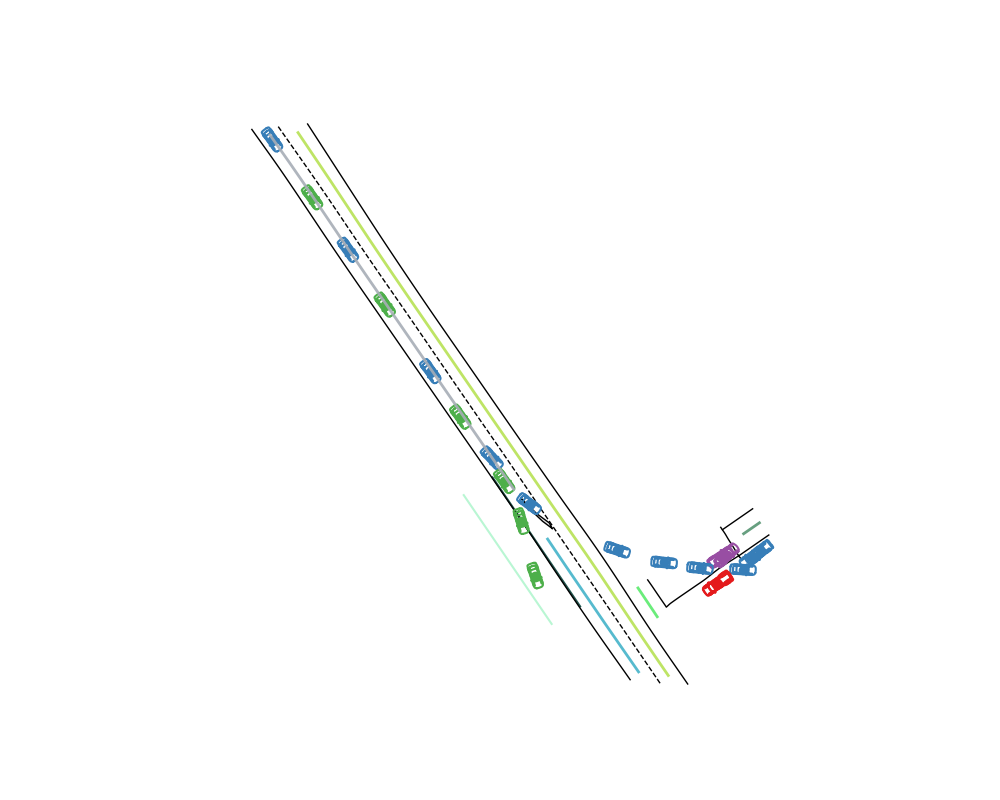

In [7]:

# list(map(lambda x: x['name'], scene['misc']))
# scene
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

def draw_symbol(ax, item, color=None):
    if color is None:
        color = np.random.rand(3)
    if item["type"] == "symbol":
        for item in item['items']:
            if item['type'] == 'symbol':
                for subitem in item['items']:
                    verts = subitem["transformed_verts"]
                    xs, ys = zip(*verts)
                    ax.plot(xs, ys, color=color)
            else:
                verts = item["transformed_verts"]
                xs, ys = zip(*verts)
                ax.plot(xs, ys, color=color)
    else:
        verts = item["transformed_verts"]
        xs, ys = zip(*verts)
        ax.plot(xs, ys, color=color)

for item in scene["road_markings"]:
    if not item["name"]:
        continue
    draw_symbol(ax, item)
    


    
for item in scene["roadway"]:
    verts = item["verts"]
    # color = np.random.rand(3)
    color = 'black'
    xs, ys = zip(*verts)
    dashed = item.get("dashed", False)
    closed = item.get("closed", False)
    thick = item.get("thick", False)
    if dashed:
        ax.plot(xs, ys, color=color, linestyle='--', linewidth=2 if thick else 1)
    else:
        ax.plot(xs, ys, color=color, linewidth=2 if thick else 1)
        if closed:
            ax.fill(xs, ys, color='lightgray', alpha=0.5)


for line in centerline_segments:
    xs, ys = zip(*line)
    # random color
    color = np.random.rand(3)
    # color = 'blue'
    ax.plot(xs, ys, color=color, linewidth=2, alpha=0.9, zorder=10)

    # # viridis color based on length 
    # cmap = plt.cm.viridis
    # norm = plt.Normalize(vmin=0, vmax=2.5)
    # color = cmap(norm(avg_length))
    # ax.plot(xs, ys, c=color, linewidth=2, alpha=0.9, zorder=10)
    # color based on angle of each segment
    # angle = np.arctan2(ys[1]-ys[0], xs[1]-xs[0])
    # angle_deg = np.degrees(angle) # Map to [0, 180]
    # cmap = plt.cm.hsv
    # norm = plt.Normalize(vmin=0, vmax=360)
    # color = cmap(norm(angle_deg))
    # ax.plot(xs, ys, c=color, linewidth=2, alpha=0.9, zorder=10)
    
# Plot filtered centerline segments in blue
# if centerline_segments:
#     lc_centerline = LineCollection(centerline_segments[0], colors='blue', linewidths=2, alpha=0.9, label='Filtered Centerline', zorder=10)
#     ax.add_collection(lc_centerline)
    
# Plot centerline points
# centerline_points = set()
# for seg in centerline_segments:
#     centerline_points.add(tuple(seg[0]))
#     centerline_points.add(tuple(seg[1]))

# if centerline_points:
    # ax.scatter(*zip(*centerline_points), color='blue', s=20, zorder=11, label='Centerline points')

# if midpoints:
#     pts = ax.scatter(*zip(*midpoints), color='blue', s=5, zorder=9, alpha=0.2, label='Midpoints')
#     cursor = mplcursors.cursor(pts, hover=True)
#     @cursor.connect("add")
#     def on_add(sel):
#         idx = int(sel.index)
#         x, y = midpoints[idx]
#         sel.annotation.set_text(f"#{idx+1}: ({x:.3f}, {y:.3f})")
#         sel.annotation.get_bbox_patch().set(alpha=0.8)


# Plot outliers with different styles based on reason
# outlier_styles = {
#     'isolated': {'color': 'red', 'marker': 'x', 'size': 40, 'label': 'Isolated (no neighbors)'},
#     'too_dense': {'color': 'orange', 'marker': 's', 'size': 30, 'label': 'Too dense (>10 neighbors)'},
#     'angle_mismatch': {'color': 'purple', 'marker': '^', 'size': 35, 'label': 'Angle mismatch'},
#     'isolated_after_filter': {'color': 'pink', 'marker': 'D', 'size': 25, 'label': 'Isolated after filtering'}
# }

# # Group outliers by reason
# outliers_by_reason = {}
# for point, reason in outlier_info.items():
#     if reason not in outliers_by_reason:
#         outliers_by_reason[reason] = []
#     outliers_by_reason[reason].append(point)

# # Plot each group with its style
# for reason, points in outliers_by_reason.items():
#     if points and reason in outlier_styles:
#         style = outlier_styles[reason]
#         ax.scatter(*zip(*points), 
#                   color=style['color'], 
#                   marker=style['marker'], 
#                   s=style['size'], 
#                   zorder=12, 
#                   label=style['label'],
#                   edgecolors='black',
#                   linewidths=0.5)

# if centroid_segments:
#     n = len(centroid_segments)
#     idx = np.arange(n)
#     cmap = plt.cm.viridis
#     norm = plt.Normalize(vmin=0, vmax=max(1, n-1))
#     colors_cent = cmap(norm(idx))
#     lc_cent = LineCollection(centroid_segments, colors=colors_cent, linewidths=1, alpha=0.7, label='Centroid connections (by index)')
#     ax.add_collection(lc_cent)
#     sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
#     sm.set_array(idx)
#     fig.colorbar(sm, ax=ax, label='centroid index')



debug_draw = False
if debug_draw:
    if centroid_segments:
        lengths = np.array([np.linalg.norm(np.asarray(a) - np.asarray(b)) for a, b in centroid_segments])
        if len(lengths) == 0:
            lc_cent = LineCollection(centroid_segments, colors='green', linewidths=1, alpha=0.3)
        else:
            vmin, vmax = lengths.min(), lengths.max()
            # avoid identical vmin/vmax
            # if vmax == vmin:
                # vmax = vmin + 1.0
            norm = plt.Normalize(vmin=vmin, vmax=vmax)
            cmap = plt.cm.viridis
            colors_cent = cmap(norm(lengths))
            lc_cent = LineCollection(centroid_segments, colors=colors_cent, linewidths=1, alpha=0.3, label='Centroid connections')
            # add colorbar
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            # sm.set_array(lengths)
            fig.colorbar(sm, ax=ax, label='centroid edge length')
        ax.add_collection(lc_cent)
    if triangle_segments:
        # tri_idx = np.arange(len(triangle_segments))
        # cmap_tri = plt.cm.viridis
        # norm_tri = plt.Normalize(vmin=0, vmax=max(1, len(triangle_segments)-1))
        # colors_tri = cmap_tri(norm_tri(tri_idx))
        # lc_tri = LineCollection(triangle_segments, colors=colors_tri, linewidths=0.5, alpha=0.6, label='Valid triangles (parallel)')
        # ax.add_collection(lc_tri)
        # sm_tri = plt.cm.ScalarMappable(cmap=cmap_tri, norm=norm_tri)
        # sm_tri.set_array(tri_idx)
        # fig.colorbar(sm_tri, ax=ax, label='triangle index')

        # Alternatively, color by length
        lengths_tri = np.array([np.linalg.norm(np.asarray(a) - np.asarray(b)) for a, b in triangle_segments])
        if len(lengths_tri) == 0:
            lc_tri = LineCollection(triangle_segments, colors='green', linewidths=0.5, alpha=0.6, label='Valid triangles (parallel)')
        else:
            vmin_tri, vmax_tri = lengths_tri.min(), lengths_tri.max()
            norm_tri = plt.Normalize(vmin=vmin_tri, vmax=vmax_tri)
            cmap_tri = plt.cm.viridis
            colors_tri = cmap_tri(norm_tri(lengths_tri))
            lc_tri = LineCollection(triangle_segments, colors=colors_tri, linewidths=0.5, alpha=0.6, label='Valid triangles (parallel)')
            # add colorbar
            sm_tri = plt.cm.ScalarMappable(cmap=cmap_tri, norm=norm_tri)
            # sm_tri.set_array(lengths_tri)
            fig.colorbar(sm_tri, ax=ax, label='triangle edge length')
        ax.add_collection(lc_tri)

    # Plot clustered triangles in red for debugging
    if clustered_triangles:
        lc_clustered = LineCollection(clustered_triangles, colors='red', linewidths=1, alpha=0.5, label='Clustered triangles (filtered)')
        ax.add_collection(lc_clustered)

    # NEW: Plot non-parallel triangles in orange for debugging
    if non_parallel_triangles:
        lc_non_parallel = LineCollection(non_parallel_triangles, colors='orange', linewidths=1, alpha=0.5, label='Non-parallel triangles (filtered)')
        ax.add_collection(lc_non_parallel)

    # Plot problematic vertices with high triangle count
    if vertex_cluster_info:
        problematic_verts = [(debug_points[v_idx], count) for v_idx, count in vertex_cluster_info.items() if count >= 10]
        if problematic_verts:
            verts, counts = zip(*problematic_verts)
            ax.scatter(*zip(*verts), color='darkred', s=100, marker='*', zorder=13, 
                    label=f'Cluster centers ({len(verts)} vertices)', edgecolors='yellow', linewidths=1)

# for item in scene["texts"]:
#     cx, cy = item["transformed_center"]
#     ax.plot(cx, cy, 'x', color='gray')


colors = plt.colormaps['Set1']
for item in scene["vehicles"]:
    color = np.random.rand(3,) # default random color
    if item["associated_text"]:
        veh_no = item["associated_text"][0]
        if veh_no.isdigit():
            color = colors(int(veh_no) % 5)
        else:
            color = np.random.rand(3,)
    draw_symbol(ax, item, color=color)
    # draw center point
    cx, cy = item["transformed_center"]
    ax.plot(cx, cy, 'o', color=color)


ax.axis('off')
ax.set_aspect('equal', 'box')
# ax.legend(loc='upper right', fontsize=8)
plt.savefig("delaunay_centerlines.png", dpi=300, bbox_inches='tight')

# # Print debug statistics
# print(f"\nOutlier Statistics:")
# for reason, points in outliers_by_reason.items():
#     pri nt(f"  {reason}: {len(points)} points")
# print(f"Total outliers: {len(outlier_info)}")
# print(f"Valid centerline points: {len(centerline_points)}")
# print(f"\nCluster Statistics:")
# print(f"Total clustered triangles: {len(clustered_triangles)}")
# print(f"Total non-parallel triangles: {len(non_parallel_triangles)}")
# print(f"Total valid triangles (parallel): {len(triangle_segments)}")
# print(f"Vertices with >=10 triangles: {sum(1 for count in vertex_cluster_info.values() if count >= 10)}")

In [8]:
# symbols = reader.symbols
# for symbol in symbols:
#     color = np.random.rand(3,)
#     for item in symbol['items']:
#         if item['type'] == 'symbol':
#             for subitem in item['items']:
#                 verts = subitem["transformed_verts"]
#                 xs, ys = zip(*verts)
#                 ax.plot(xs, ys, color=color)
#             continue
        
#         verts = item["transformed_verts"]

#         xs, ys = zip(*verts)
#         ax.plot(xs, ys, color=color)

In [9]:
# # Create a grid of road drawings from random files
# fig, axes = plt.subplots(3, 3, figsize=(15, 15))
# axes = axes.flatten()

# for idx, ax in enumerate(axes):
#     # Select a random file
#     random_filename = random.choice(far_files)
#     random_file = os.path.join(folder, random_filename)
    
#     try:
#         # Parse the file
#         temp_reader = FaroSceneGraphReader(random_file, cls_cache=string_table)
#         temp_scene = temp_reader.parse()
        
#         # Draw road markings
#         for item in temp_scene["road_markings"]:
#             if not item["name"]:
#                 continue
#             draw_symbol(ax, item)
        
#         # Draw vehicles with colors
#         colors_temp = plt.cm.get_cmap('Set1', 5)
#         for item in temp_scene["vehicles"]:
#             color = np.random.rand(3,)
#             if item["associated_text"]:
#                 veh_no = item["associated_text"][0]
#                 if veh_no.isdigit():
#                     color = colors_temp(int(veh_no) % 5)
#             draw_symbol(ax, item, color=color)
#             cx, cy = item["transformed_center"]
#             ax.plot(cx, cy, 'o', color=color, markersize=3)
        
#         # Draw roadway
#         for item in temp_scene["roadway"]:
#             verts = item["verts"]
#             xs, ys = zip(*verts)
#             if item.get("dashed", False):
#                 ax.plot(xs, ys, color='black', linestyle='--', linewidth=0.5)
#             else:
#                 ax.plot(xs, ys, color='black', linewidth=0.5)
            
#             if item.get("closed", False):
#                 ax.plot([xs[0], xs[-1]], [ys[0], ys[-1]], color='black', linewidth=0.5)
#                 ax.fill(xs, ys, color='lightgray', alpha=0.5)
        
#         ax.set_aspect('equal', 'box')
#         ax.set_title(f'{random_filename.split("_")[0]}', fontsize=8)
#         ax.axis('off')
        
#     except Exception as e:
#         ax.text(0.5, 0.5, f'Error loading file', ha='center', va='center', transform=ax.transAxes)
#         ax.axis('off')

# plt.tight_layout()
# plt.show()

In [10]:
# ============================================================================
# VEHICLE TRAJECTORY ORDERING AND COLLISION DETECTION
# ============================================================================

from itertools import permutations

class OrientedBoundingBox:
    """OBB for higher-fidelity collision detection."""
    
    def __init__(self, center, half_extents, rotation_angle):
        self.center = np.array(center)  # (x, y) in WORLD coordinates
        self.half_extents = np.array(half_extents)  # scaled dimensions
        self.angle = rotation_angle  # radians

    @classmethod
    def from_vehicle_symbol(cls, symbol):
        """Extract OBB from vehicle symbol using transform matrix."""
        transform = symbol["transform"]

        # Extract scale factors from the transform
        # For M = T @ R @ S: column vectors have length = scale
        sx = np.sqrt(transform[0, 0]**2 + transform[1, 0]**2)
        sy = np.sqrt(transform[0, 1]**2 + transform[1, 1]**2)

        # Extract rotation (after removing scale)
        angle = np.arctan2(transform[1, 0] / sx, transform[0, 0] / sx)

        # Get LOCAL bbox and compute half extents, then APPLY SCALE
        bbox = symbol["bbox"]
        half_w = (bbox[2] - bbox[0]) / 2 * sx
        half_h = (bbox[3] - bbox[1]) / 2 * sy

        center = symbol["transformed_center"]
        return cls(center, (half_w, half_h), angle)

    def get_corners(self):
        """Return 4 corners of the OBB in world coordinates."""
        c, s = np.cos(self.angle), np.sin(self.angle)
        R = np.array([[c, -s], [s, c]])

        corners_local = np.array([
            [-self.half_extents[0], -self.half_extents[1]],
            [ self.half_extents[0], -self.half_extents[1]],
            [ self.half_extents[0],  self.half_extents[1]],
            [-self.half_extents[0],  self.half_extents[1]],
        ])
        return (R @ corners_local.T).T + self.center


def obb_intersect(obb1, obb2):
    """Separating Axis Theorem (SAT) for OBB-OBB intersection."""
    def get_axes(obb):
        c, s = np.cos(obb.angle), np.sin(obb.angle)
        return [np.array([c, s]), np.array([-s, c])]

    corners1 = obb1.get_corners()
    corners2 = obb2.get_corners()

    for axis in get_axes(obb1) + get_axes(obb2):
        proj1 = corners1 @ axis
        proj2 = corners2 @ axis
        if max(proj1) < min(proj2) or max(proj2) < min(proj1):
            return False  # Separating axis found
    return True  # No separating axis = collision


def project_obb_onto_axis(obb, axis):
    """Project OBB half-extent onto given axis."""
    c, s = np.cos(obb.angle), np.sin(obb.angle)
    local_axes = [np.array([c, s]), np.array([-s, c])]

    return sum(
        abs(np.dot(local_axis, axis)) * half_ext
        for local_axis, half_ext in zip(local_axes, obb.half_extents)
    )


def compute_penetration_depth(obb1, obb2):
    """
    Compute approximate penetration depth between two OBBs.
    Simplified: distance between centers minus sum of extents along center axis.
    """
    center_diff = obb2.center - obb1.center
    center_dist = np.linalg.norm(center_diff)

    if center_dist < 1e-6:
        # OBBs are concentric, return max extent
        return np.linalg.norm(obb1.half_extents) + np.linalg.norm(obb2.half_extents)

    # Project extents onto center-to-center axis
    axis = center_diff / center_dist
    proj1 = project_obb_onto_axis(obb1, axis)
    proj2 = project_obb_onto_axis(obb2, axis)

    # Penetration = overlap of projections
    return max(0, (proj1 + proj2) - center_dist)


# ============================================================================
# VEHICLE LABEL VALIDATION AND GROUPING
# ============================================================================

def validate_vehicle_labels(vehicles):
    """Ensure all vehicles have labels. Raise error if any unlabeled."""
    unlabeled = [v for v in vehicles if not v["associated_text"]
                 or not any(t.strip().isdigit() for t in v["associated_text"])]
    if unlabeled:
        raise ValueError(f"Found {len(unlabeled)} unlabeled vehicles. "
                        "User annotation required.")
    return True


def group_vehicles_by_label(vehicles):
    """Group all vehicle positions by their label number."""
    groups = {}  # label -> list of vehicle symbols
    for v in vehicles:
        label = next((t for t in v["associated_text"] if t.strip().isdigit()), None)
        if label:
            groups.setdefault(label, []).append(v)
    return groups


# ============================================================================
# TSP-BASED TRAJECTORY ORDERING (Distance + Angle Score)
# ============================================================================

def get_vehicle_heading(symbol):
    """Extract heading angle from vehicle transform matrix."""
    transform = symbol["transform"]
    sx = np.sqrt(transform[0, 0]**2 + transform[1, 0]**2)
    return np.arctan2(transform[1, 0] / sx, transform[0, 0] / sx)


def angle_difference(a1, a2):
    """Compute smallest signed angle difference."""
    diff = a1 - a2
    return np.arctan2(np.sin(diff), np.cos(diff))


def compute_edge_score(pos_from, pos_to, distance_weight=1.0, angle_weight=0.5):
    """
    Score for transitioning from pos_from to pos_to.
    Lower score = more physically plausible transition.
    """
    from_pos = np.array(pos_from["transformed_center"])
    to_pos = np.array(pos_to["transformed_center"])

    # Distance component
    distance = np.linalg.norm(to_pos - from_pos)

    # Movement direction
    move_direction = np.arctan2(to_pos[1] - from_pos[1], to_pos[0] - from_pos[0])

    # Vehicle heading at "from" position
    from_heading = get_vehicle_heading(pos_from)

    # Angle between movement and heading (vehicle should move forward)
    heading_alignment = abs(angle_difference(move_direction, from_heading))
    angle_penalty = heading_alignment / np.pi  # 0 = forward, 1 = backward

    # Heading continuity (smooth rotation)
    to_heading = get_vehicle_heading(pos_to)
    heading_change = abs(angle_difference(to_heading, from_heading))
    continuity_penalty = heading_change / np.pi

    return (distance_weight * distance +
            angle_weight * angle_penalty * distance +
            angle_weight * 0.5 * continuity_penalty * distance)


def compute_path_score(positions, order):
    """Compute total score for a given ordering of positions."""
    total = 0.0
    ordered_positions = [positions[i] for i in order]
    for i in range(len(ordered_positions) - 1):
        total += compute_edge_score(ordered_positions[i], ordered_positions[i + 1])
    return total


def tsp_bruteforce(positions):
    """
    Find optimal ordering via brute-force permutation search.
    Feasible for n <= 8 (8! = 40320).
    """
    n = len(positions)
    if n <= 1:
        return list(range(n)), 0.0

    best_order = None
    best_score = float('inf')

    for perm in permutations(range(n)):
        score = compute_path_score(positions, perm)
        if score < best_score:
            best_score = score
            best_order = list(perm)

    return best_order, best_score


def tsp_greedy_2opt(positions):
    """
    Greedy nearest-neighbor with 2-opt improvement.
    For n > 8 where brute-force is too slow.
    """
    n = len(positions)
    if n <= 1:
        return list(range(n)), 0.0

    # Greedy nearest-neighbor starting from each position
    best_order = None
    best_score = float('inf')

    for start in range(n):
        order = [start]
        remaining = set(range(n)) - {start}

        while remaining:
            current = order[-1]
            # Find nearest neighbor by edge score
            best_next = min(remaining,
                           key=lambda x: compute_edge_score(positions[current], positions[x]))
            order.append(best_next)
            remaining.remove(best_next)

        # 2-opt improvement
        improved = True
        while improved:
            improved = False
            for i in range(1, n - 1):
                for j in range(i + 1, n):
                    # Try reversing segment [i:j+1]
                    new_order = order[:i] + order[i:j+1][::-1] + order[j+1:]
                    new_score = compute_path_score(positions, new_order)
                    if new_score < compute_path_score(positions, order):
                        order = new_order
                        improved = True

        score = compute_path_score(positions, order)
        if score < best_score:
            best_score = score
            best_order = order

    return best_order, best_score


def order_vehicle_trajectory_tsp(positions, bruteforce_threshold=8):
    """
    Order vehicle positions using TSP with the score function.

    Args:
        positions: list of vehicle position symbols
        bruteforce_threshold: use brute-force for n <= this value

    Returns:
        ordered: list of positions in chronological order
        score: total path score (lower = better)
    """
    n = len(positions)
    if n <= 1:
        return positions, 0.0

    if n <= bruteforce_threshold:
        order, score = tsp_bruteforce(positions)
    else:
        order, score = tsp_greedy_2opt(positions)

    return [positions[i] for i in order], score


# ============================================================================
# COLLISION DETECTION (EXHAUSTIVE FOR SMALL N)
# ============================================================================

def find_all_collision_pairs(vehicle_trajectories):
    """
    Find all position pairs that result in collision between any two vehicles.

    Args:
        vehicle_trajectories: dict of label -> ordered list of positions

    Returns:
        list of collision info dicts
    """
    labels = list(vehicle_trajectories.keys())
    collisions = []

    # Build OBBs for all positions
    all_obbs = {}
    for label, positions in vehicle_trajectories.items():
        all_obbs[label] = [OrientedBoundingBox.from_vehicle_symbol(p) for p in positions]

    # Check ALL position pairs between vehicles (exhaustive for small N)
    for i, label1 in enumerate(labels):
        for label2 in labels[i+1:]:
            for idx1, obb1 in enumerate(all_obbs[label1]):
                for idx2, obb2 in enumerate(all_obbs[label2]):
                    if obb_intersect(obb1, obb2):
                        collisions.append({
                            "vehicles": (label1, label2),
                            "indices": (idx1, idx2),
                            "obb1": obb1,
                            "obb2": obb2,
                            "penetration": compute_penetration_depth(obb1, obb2),
                        })

    return collisions


def find_first_collision(vehicle_trajectories):
    """
    Find the FIRST collision in chronological order.

    Strategy:
    1. Find all colliding position pairs
    2. For each collision, compute its "time" as normalized index average
       (earlier indices = earlier in trajectory = earlier in time)
    3. Return the collision with minimum time score
    4. Break ties by minimum penetration (closest to first contact)
    """
    collisions = find_all_collision_pairs(vehicle_trajectories)

    if not collisions:
        return None

    def collision_time_score(collision):
        """
        Lower score = earlier collision.
        Uses average trajectory index as proxy for time.
        """
        idx1, idx2 = collision["indices"]
        n1 = len(vehicle_trajectories[collision["vehicles"][0]])
        n2 = len(vehicle_trajectories[collision["vehicles"][1]])

        # Normalize indices to [0, 1] range (0 = start, 1 = end)
        norm_idx1 = idx1 / max(1, n1 - 1)
        norm_idx2 = idx2 / max(1, n2 - 1)

        # Average normalized position as time proxy
        return (norm_idx1 + norm_idx2) / 2

    # Sort by time, then by penetration (smaller penetration = first contact)
    collisions.sort(key=lambda c: (collision_time_score(c), c["penetration"]))

    return collisions[0]


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def extract_vehicle_chronology(scene):
    """
    Main function to extract chronological vehicle ordering using TSP.

    Args:
        scene: Parsed scene from FaroSceneGraphReader

    Returns:
        dict with:
        - trajectories: dict of label -> ordered positions
        - collision: first collision info or None
        - scores: dict of label -> TSP path score (lower = better)

    Raises:
        ValueError: If any vehicles are unlabeled (user must annotate)
    """
    vehicles = scene["vehicles"]

    # Step 1: Validate labels (ERROR if unlabeled)
    validate_vehicle_labels(vehicles)

    # Step 2: Group by label
    groups = group_vehicles_by_label(vehicles)

    # Step 3: Order each group using TSP
    trajectories = {}
    scores = {}

    for label, group in groups.items():
        ordered, score = order_vehicle_trajectory_tsp(group)
        trajectories[label] = ordered
        scores[label] = score

    # Step 4: Find first collision
    collision = find_first_collision(trajectories)

    return {
        "trajectories": trajectories,
        "collision": collision,
        "scores": scores,
    }


print("Vehicle trajectory ordering (TSP) and collision detection loaded.")

Vehicle trajectory ordering (TSP) and collision detection loaded.


In [11]:
# ============================================================================
# TEST: Extract vehicle chronology from the current scene using TSP
# ============================================================================

# Re-parse the scene to get fresh data
reader = FaroSceneGraphReader(file, cls_cache=string_table)
scene = reader.parse()

print(f"Found {len(scene['vehicles'])} vehicles")

# Show vehicle info
print("\nVehicle info:")
for v in scene["vehicles"]:
    label = v["associated_text"][0] if v["associated_text"] else "unlabeled"
    print(f"  Vehicle {label}: name={v['name']}, center={v['transformed_center']}")

# Try to extract chronology using TSP
try:
    result = extract_vehicle_chronology(scene)
    
    print(f"\n=== TSP TRAJECTORY ORDERING RESULTS ===")
    print(f"Number of vehicle groups: {len(result['trajectories'])}")
    
    for label, positions in result['trajectories'].items():
        print(f"\nVehicle {label}: {len(positions)} positions")
        print(f"  TSP path score: {result['scores'][label]:.2f}")
        for i, pos in enumerate(positions):
            heading = np.degrees(get_vehicle_heading(pos))
            print(f"    [{i}] center={pos['transformed_center']}, heading={heading:.1f} deg")
    
    if result['collision']:
        c = result['collision']
        print(f"\n=== FIRST COLLISION ===")
        print(f"  Vehicles: {c['vehicles']}")
        print(f"  At trajectory indices: {c['indices']}")
        print(f"  Penetration depth: {c['penetration']:.2f}")
    else:
        print("\nNo collision detected between any vehicle positions.")

except ValueError as e:
    print(f"Error: {e}")

Extracted 16 primitives and 26 symbols.
Classifying symbols for vehicle candidates...
Found 21 vehicles

Vehicle info:
  Vehicle 1: name=pass car solid large V1, center=(np.float64(-84.9433596134186), np.float64(80.2325057983398))
  Vehicle 1: name=pass car solid large V1, center=(np.float64(67.46745300293), np.float64(12.5403289794922))
  Vehicle 2: name=pass car solid large V2, center=(np.float64(-77.4071047306061), np.float64(66.1720886230469))
  Vehicle 2: name=pass car solid large V2, center=(np.float64(-58.6058199405667), np.float64(8.86857604980469))
  Vehicle 3: name=None, center=(np.float64(57.4865857923764), np.float64(21.2061368016132))
  Vehicle 3: name=None, center=(np.float64(53.8420722193961), np.float64(19.9288783842779))
  Vehicle 5: name=None, center=(np.float64(52.1771542958505), np.float64(3.85790252739237))
  Vehicle 5: name=None, center=(np.float64(51.7625129463333), np.float64(4.14855193818404))
  Vehicle 6: name=None, center=(np.float64(77.5003820774177), np.flo

/tmp/ipykernel_3384784/3068442253.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  vehicle_colors = plt.cm.get_cmap('tab10', len(result['trajectories']))


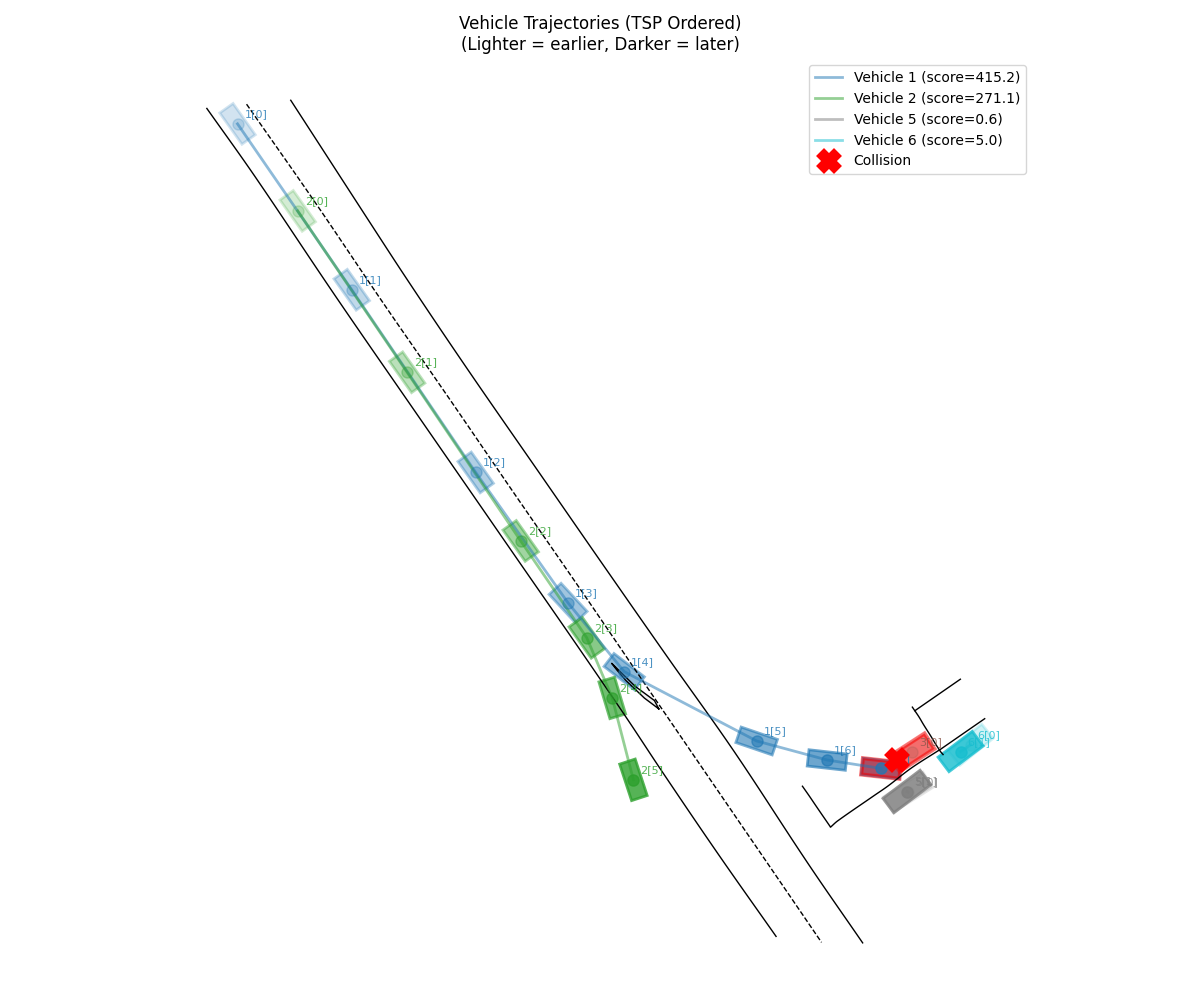

In [12]:
# ============================================================================
# VISUALIZATION: Ordered trajectories with OBBs (TSP ordering)
# ============================================================================

from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

def draw_obb(ax, obb, color='blue', alpha=0.3, linewidth=1):
    """Draw an OBB on the matplotlib axis."""
    corners = obb.get_corners()
    polygon = Polygon(corners, closed=True, fill=True, 
                      facecolor=color, edgecolor=color, 
                      alpha=alpha, linewidth=linewidth)
    ax.add_patch(polygon)
    return polygon

# Only visualize if we have results
if 'result' in dir() and result is not None:
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Draw roadway
    for item in scene["roadway"]:
        verts = item["verts"]
        xs, ys = zip(*verts)
        dashed = item.get("dashed", False)
        closed = item.get("closed", False)
        if dashed:
            ax.plot(xs, ys, color='black', linestyle='--', linewidth=1)
        else:
            ax.plot(xs, ys, color='black', linewidth=1)
            if closed:
                ax.fill(xs, ys, color='lightgray', alpha=0.3)
    
    # Color maps for different vehicles
    vehicle_colors = plt.cm.get_cmap('tab10', len(result['trajectories']))
    # Draw each vehicle's trajectory UP TO the first collision
    for vid, (label, positions) in enumerate(result['trajectories'].items()):
        base_color = vehicle_colors(vid)
        n_positions = len(positions)
        
        # Determine cutoff index if this vehicle is involved in collision
        max_index = n_positions - 1
        if result['collision']:
            c = result['collision']
            if label in c['vehicles']:
                # Get the collision index for this vehicle
                collision_idx = c['indices'][0] if c['vehicles'][0] == label else c['indices'][1]
                max_index = collision_idx
        
        # Create gradient from light to dark
        for i, pos in enumerate(positions):
            # Skip positions after collision
            if i > max_index:
                continue
            
            # Alpha increases along trajectory (darker = later)
            alpha = 0.2 + 0.6 * (i / max(1, n_positions - 1))
            
            obb = OrientedBoundingBox.from_vehicle_symbol(pos)
            draw_obb(ax, obb, color=base_color, alpha=alpha, linewidth=2)
            
            # Draw center point
            cx, cy = pos["transformed_center"]
            ax.plot(cx, cy, 'o', color=base_color, markersize=8, 
                    alpha=alpha, zorder=10)
            
            # Label with step number
            ax.annotate(f"{label}[{i}]", (cx, cy), 
                        textcoords="offset points", xytext=(5, 5),
                        fontsize=8, color=base_color, alpha=0.8)
        
        # Draw trajectory line connecting centers (only up to collision)
        if max_index >= 1:
            centers = [positions[i]["transformed_center"] for i in range(max_index + 1)]
            xs, ys = zip(*centers)
            ax.plot(xs, ys, '-', color=base_color, linewidth=2, 
                    alpha=0.5, label=f'Vehicle {label} (score={result["scores"][label]:.1f})')
    # # Draw each vehicle's trajectory
    # for vid, (label, positions) in enumerate(result['trajectories'].items()):
    #     base_color = vehicle_colors(vid)
    #     n_positions = len(positions)
        
    #     # Create gradient from light to dark
    #     for i, pos in enumerate(positions):
    #         # Alpha increases along trajectory (darker = later)
    #         alpha = 0.2 + 0.6 * (i / max(1, n_positions - 1))
            
    #         obb = OrientedBoundingBox.from_vehicle_symbol(pos)
    #         draw_obb(ax, obb, color=base_color, alpha=alpha, linewidth=2)
            
    #         # Draw center point
    #         cx, cy = pos["transformed_center"]
    #         ax.plot(cx, cy, 'o', color=base_color, markersize=8, 
    #                 alpha=alpha, zorder=10)
            
    #         # Label with step number
    #         ax.annotate(f"{label}[{i}]", (cx, cy), 
    #                    textcoords="offset points", xytext=(5, 5),
    #                    fontsize=8, color=base_color, alpha=0.8)
        
    #     # Draw trajectory line connecting centers
    #     if n_positions > 1:
    #         centers = [p["transformed_center"] for p in positions]
    #         xs, ys = zip(*centers)
    #         ax.plot(xs, ys, '-', color=base_color, linewidth=2, 
    #                 alpha=0.5, label=f'Vehicle {label} (score={result["scores"][label]:.1f})')
    
    # Highlight collision point
    if result['collision']:
        c = result['collision']
        # Draw collision OBBs with red
        draw_obb(ax, c['obb1'], color='red', alpha=0.5, linewidth=3)
        draw_obb(ax, c['obb2'], color='red', alpha=0.5, linewidth=3)
        
        # Draw midpoint
        collision_center = (c['obb1'].center + c['obb2'].center) / 2
        ax.plot(collision_center[0], collision_center[1], 'X', 
                color='red', markersize=15, markeredgewidth=3, 
                zorder=20, label='Collision')
    
    ax.set_aspect('equal', 'box')
    ax.axis('off')
    ax.legend(loc='upper right')
    ax.set_title('Vehicle Trajectories (TSP Ordered)\n(Lighter = earlier, Darker = later)')
    plt.tight_layout()
    plt.show()
else:
    print("No trajectory results to visualize. Run the extraction cell first.")